In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

In [3]:
organizations = pd.read_csv("organizations.csv")
indicator_values = pd.read_csv("indicator_values.csv")
reports = pd.read_csv("reports.csv")

print("Организаций:", organizations.shape)
print("Индикаторов:", indicator_values.shape)
print("Отчетов:", reports.shape)

Организаций: (2510, 15)
Индикаторов: (4925890, 7)
Отчетов: (300741, 7)


In [4]:
indicator_values = indicator_values[indicator_values["is_fact"] == True]
indicator_values = indicator_values.dropna(subset=["value"])

reports["accept_timestamp"] = pd.to_datetime(
    reports["accept_timestamp"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)


In [5]:
def calculate_energy_features(df):
    features = []

    for org_id, group in df.groupby("organization"):

        values = group["value"].values
        years = group["year"].values

        if len(values) < 5:
            continue

        mean_value = np.mean(values)
        std_value = np.std(values)
        cv = std_value / mean_value if mean_value != 0 else 0

        X_year = years.reshape(-1, 1)
        model = LinearRegression()
        model.fit(X_year, values)
        trend = model.coef_[0]

        anomalies = np.sum(np.abs(values - mean_value) > 3 * std_value)
        anomaly_share = anomalies / len(values)

        features.append({
            "organization": org_id,
            "mean_energy": mean_value,
            "trend_energy": trend,
            "cv_energy": cv,
            "anomaly_share": anomaly_share
        })

    return pd.DataFrame(features)

energy_features = calculate_energy_features(indicator_values)
energy_features.head()

,organization,mean_energy,trend_energy,cv_energy,anomaly_share
0,1,1.408776e+07,-112481.159757,5.701957,0.009562
1,2,1.468538e+06,-195376.898683,23.855765,0.001506
2,3,1.415051e+05,-24032.900731,5.378182,0.014337
3,4,6.530834e+03,-630.840892,19.671094,0.001803
4,6,1.381622e+04,-631.766911,6.275272,0.009877


In [6]:
def get_deadline(year, quarter):

    if pd.isna(year):
        return None

    if pd.isna(quarter):
        quarter = 4

    year = int(year)
    quarter = int(quarter)

    if quarter == 1:
        return pd.Timestamp(year=year, month=4, day=30)
    elif quarter == 2:
        return pd.Timestamp(year=year, month=7, day=31)
    elif quarter == 3:
        return pd.Timestamp(year=year, month=10, day=31)
    else:
        return pd.Timestamp(year=year + 1, month=1, day=31)


discipline_features = []

for org_id, group in reports.groupby("src_organization"):

    total = len(group)
    if total == 0:
        continue

    timely = 0

    for _, row in group.iterrows():

        if pd.isna(row["accept_timestamp"]):
            continue

        deadline = get_deadline(row["year"], row["quarter"])
        if deadline is None:
            continue

        if row["accept_timestamp"] <= deadline:
            timely += 1

    discipline_features.append({
        "organization": org_id,
        "report_timeliness": timely / total if total > 0 else 0,
        "series_length": group["year"].dropna().nunique()
    })

discipline_features = pd.DataFrame(discipline_features)
discipline_features.head()

,organization,report_timeliness,series_length
0,1,0.083102,16
1,2,0.211268,13
2,3,0.284047,12
3,4,0.269531,13
4,6,0.273649,12


In [7]:
dataset = energy_features.merge(
    discipline_features,
    on="organization",
    how="inner"
)

dataset = dataset.dropna()

print("Финальный датасет:", dataset.shape)
dataset.head()

Финальный датасет: (2013, 7)


,organization,mean_energy,trend_energy,cv_energy,anomaly_share,report_timeliness,series_length
0,1,1.408776e+07,-112481.159757,5.701957,0.009562,0.083102,16
1,2,1.468538e+06,-195376.898683,23.855765,0.001506,0.211268,13
2,3,1.415051e+05,-24032.900731,5.378182,0.014337,0.284047,12
3,4,6.530834e+03,-630.840892,19.671094,0.001803,0.269531,13
4,6,1.381622e+04,-631.766911,6.275272,0.009877,0.273649,12


<Figure size 1200x800 with 0 Axes>

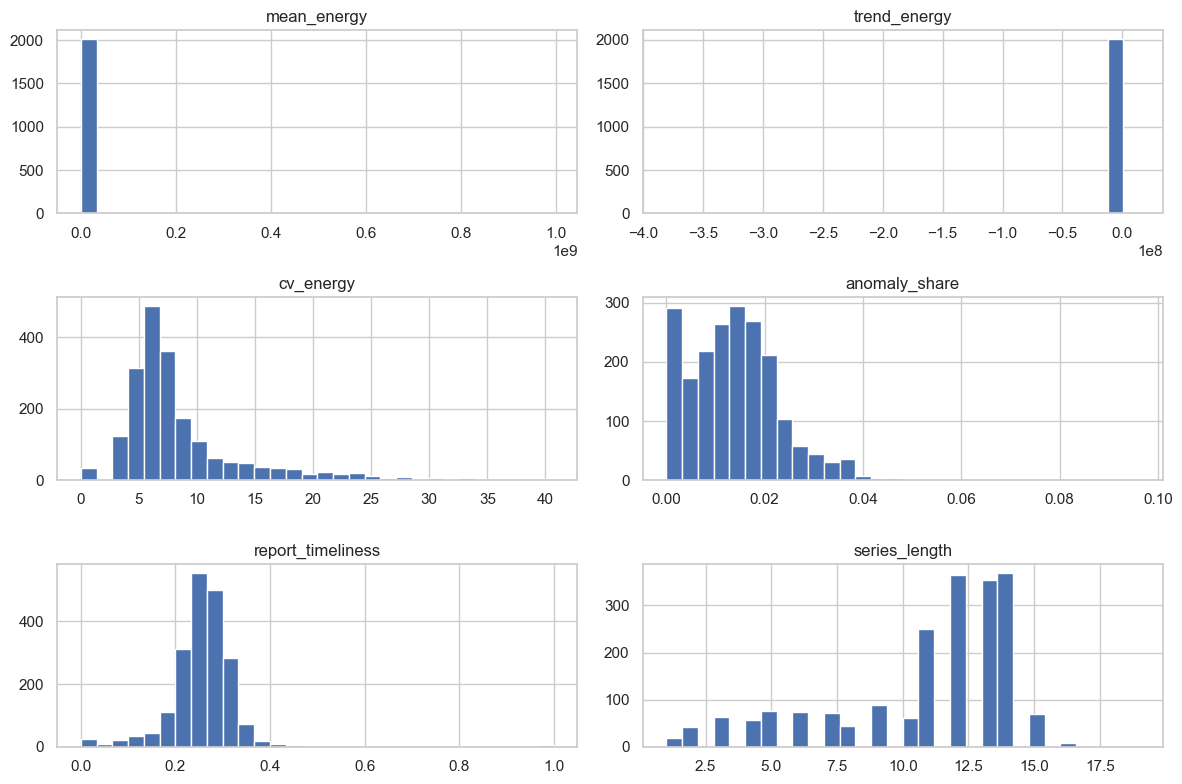

In [8]:
dataset.describe()

plt.figure(figsize=(12,8))
dataset.drop(columns=["organization"]).hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

In [9]:
X = dataset.drop(columns=["organization"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

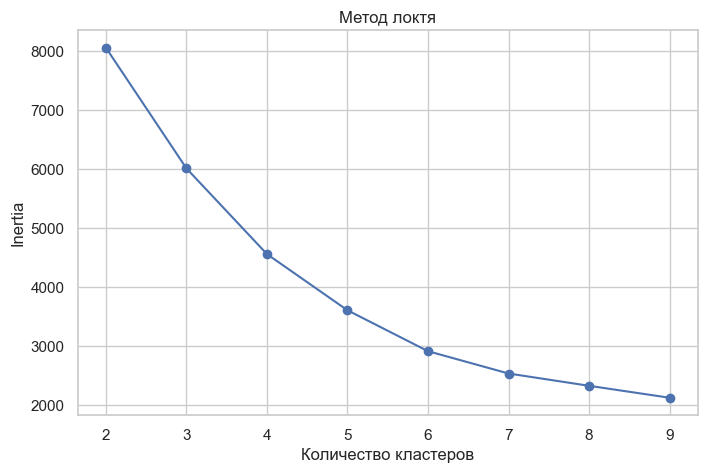

In [10]:
inertia = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,10), inertia, marker="o")
plt.title("Метод локтя")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

dataset["cluster"] = labels
dataset.head()

,organization,mean_energy,trend_energy,cv_energy,anomaly_share,report_timeliness,series_length,cluster
0,1,1.408776e+07,-112481.159757,5.701957,0.009562,0.083102,16,0
1,2,1.468538e+06,-195376.898683,23.855765,0.001506,0.211268,13,3
2,3,1.415051e+05,-24032.900731,5.378182,0.014337,0.284047,12,0
3,4,6.530834e+03,-630.840892,19.671094,0.001803,0.269531,13,3
4,6,1.381622e+04,-631.766911,6.275272,0.009877,0.273649,12,0


In [12]:
sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", dbi)
print("Calinski-Harabasz Index:", ch)

Silhouette Score: 0.4065766485036747
Davies-Bouldin Index: 0.906040977577332
Calinski-Harabasz Index: 1102.4055342200465


In [13]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=X.columns
)

centroids_df["cluster"] = range(len(centroids_df))
centroids_df

,mean_energy,trend_energy,cv_energy,anomaly_share,report_timeliness,series_length,cluster
0,8.185045e+04,-5.877969e+03,6.818228,0.014956,0.264974,12.469984,0
1,8.878785e+04,-6.580016e+03,5.836253,0.019826,0.234437,5.107843,1
2,9.962282e+08,-3.809737e+08,34.007273,0.000861,0.287129,11.000000,2
3,6.969101e+05,-1.491287e+04,19.265835,0.002353,0.261544,11.372781,3


In [14]:
cluster_sizes = dataset["cluster"].value_counts().reset_index()
cluster_sizes.columns = ["cluster", "count"]
cluster_sizes

,cluster,count
0,0,1266
1,1,408
2,3,338
3,2,1


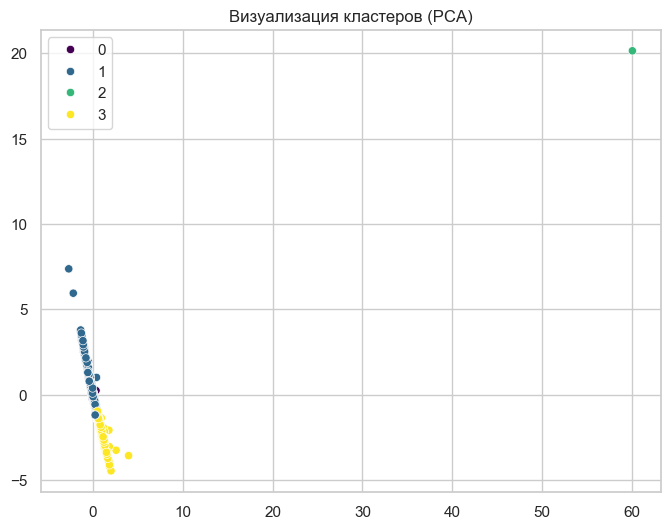

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="viridis")
plt.title("Визуализация кластеров (PCA)")
plt.show()

In [16]:
scores = []

for seed in range(5):
    model = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels_tmp = model.fit_predict(X_scaled)
    sil_tmp = silhouette_score(X_scaled, labels_tmp)
    scores.append(sil_tmp)

print("Silhouette при разных random_state:", scores)
print("Среднее:", np.mean(scores))

Silhouette при разных random_state: [0.40605362673361994, 0.4065766485036747, 0.40631159710747655, 0.40605362673361994, 0.40631159710747655]
Среднее: 0.4062614192371735


In [24]:
org_filtered = organizations.copy()

# Удаляем архивные по булевому полю (если есть)
if "archived" in org_filtered.columns:
    org_filtered = org_filtered[org_filtered["archived"] == False]

# Удаляем ликвидированные по названию
org_filtered = org_filtered[
    ~org_filtered["name"].str.contains("ЛИКВИД", case=False, na=False)
]

# Удаляем тестовые по названию
org_filtered = org_filtered[
    ~org_filtered["name"].str.contains("ТЕСТ", case=False, na=False)
]

print("После фильтрации организаций:", org_filtered.shape)

После фильтрации организаций: (2235, 15)


In [25]:
valid_ids = org_filtered["id"].unique()

indicator_values_filtered = indicator_values[
    indicator_values["organization"].isin(valid_ids)
]

In [26]:
selected_ips = ["IP7", "IP10", "IP13", "IP16", "IP20"]

ip_subset = indicator_values_filtered[
    indicator_values_filtered["code"].isin(selected_ips)
]

ip_agg = (
    ip_subset
    .groupby(["organization", "code"])["value"]
    .mean()
    .unstack()
    .reset_index()
)

In [27]:
org_names = org_filtered[["id", "name"]]
org_names.columns = ["organization", "org_name"]

ip_agg = ip_agg.merge(org_names, on="organization", how="inner")

In [28]:
ip_agg["total_energy"] = ip_agg[selected_ips].fillna(0).sum(axis=1)

ip_agg = ip_agg[ip_agg["total_energy"] > 0]

ip_agg_sorted = ip_agg.sort_values("total_energy", ascending=False)

In [29]:
top_20 = ip_agg_sorted.head(20)
bottom_20 = ip_agg_sorted.tail(20)

print("\nТОП-20 по суммарному энергопотреблению:")
display(top_20[["org_name", "total_energy"]])

print("\nBOTTOM-20 по суммарному энергопотреблению:")
display(bottom_20[["org_name", "total_energy"]])


ТОП-20 по суммарному энергопотреблению:


,org_name,total_energy
945,Государственное бюджетное общеобразовательное ...,4.605427e+09
130,Государственное бюджетное учреждение здравоохр...,1.056813e+07
142,Государственное бюджетное учреждение здравоохр...,3.537646e+06
223,Государственное бюджетное учреждение здравоохр...,2.388092e+06
109,Государственное бюджетное учреждение здравоохр...,2.286761e+06
1483,Ленинградское областное государственное бюджет...,2.175906e+06
222,Государственное Бюджетное Учреждение Здравоохр...,2.020043e+06
625,Государственное автономное учреждение Ленингра...,1.714405e+06
1070,ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХР...,1.564877e+06
1190,Муниципальное автономное учреждение «ОЛИМП»,1.348308e+06



BOTTOM-20 по суммарному энергопотреблению:


,org_name,total_energy
852,Муниципальное казенное образовательное учрежде...,62.122758
620,Муниципальное учреждение дополнительного образ...,55.515553
1329,"Муниципальное казенное учреждение для детей, н...",50.500000
569,Ленинградское областное государственное казенн...,50.017043
646,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""СЛУЖБА ЗАКА...",48.178571
1394,"МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ""ПУДОМЯГСКИ...",47.275974
6,Государственное казённое учреждение Ленинградс...,30.235294
1450,"Муниципальное казенное учреждение ""Центр образ...",24.143545
1435,Муниципальное казенное учреждение «Городской и...,15.798552
1215,"Бюджетное муниципальное учреждение ""Токсовская...",12.351877


In [30]:
X_ip = ip_agg[selected_ips].fillna(0)

scaler_ip = StandardScaler()
X_ip_scaled = scaler_ip.fit_transform(X_ip)

kmeans_ip = KMeans(n_clusters=3, random_state=42, n_init=10)
ip_labels = kmeans_ip.fit_predict(X_ip_scaled)

ip_agg["energy_cluster"] = ip_labels


# Средние значения по кластерам
cluster_summary = (
    ip_agg
    .groupby("energy_cluster")["total_energy"]
    .mean()
    .sort_values()
)

print("\nСредние значения total_energy по 3 кластерам:")
display(cluster_summary)


Средние значения total_energy по 3 кластерам:


energy_cluster
0    9.142585e+04
1    1.922000e+06
2    4.605427e+09
Name: total_energy, dtype: float64